# Clean Energy Market Segmentation and CO₂ Emissions Analysis with Forecasting and Regression

## 1. Business Understanding

### 1.1. Project Overview

Climate change is a major global challenge driven largely by greenhouse gas emissions, particularly carbon dioxide (CO₂). However, emission patterns differ significantly across countries due to differences in population, economic activity, energy consumption, and dependence on fossil fuels.

Understanding both the *current emission characteristics of countries* and *how emissions are likely to change over time* can support governments, environmental organizations, and policymakers in developing more targeted climate strategies.

This project uses historical country-level CO₂ emissions data to examine emission patterns through two complementary machine learning approaches: *classification and time-series forecasting*.

### 1.2. Business Problem

Countries have different levels and patterns of CO₂ emissions, making it difficult to apply the same environmental strategies across all regions. In addition, historical emission trends alone do not provide sufficient information about how emissions may develop in the future.

Therefore, there is a need to:

1. Identify and classify countries according to meaningful CO₂ emission characteristics using demographic, economic, energy, and emission-related factors.
2. Analyze historical CO₂ emission patterns over time and forecast future emission trends.

Combining classification and time-series forecasting provides both a *comparative view of emission profiles* and a *forward-looking view of how emissions may change over time*.

### 1.3. Project Objectives

The main objective of this project is to use historical CO₂ emissions data to understand emission patterns across countries and predict future emission trends.

The specific objectives are:

- Explore historical CO₂ emission patterns across countries and over time.
- Identify economic, demographic, energy, and emission-related factors associated with differences in CO₂ emissions.
- Develop a *classification model* to categorize country observations according to defined CO₂ emission levels or profiles.
- Develop a *time-series forecasting model* to predict future CO₂ emissions using historical emission patterns.
- Compare model performance using appropriate classification and forecasting evaluation metrics.
- Generate insights that can support environmental planning and climate-related decision-making.

### 1.4. Modeling Approach

The project will use two modeling approaches:

*1. Classification*

Classification models will be used to categorize observations into defined CO₂ emission classes. Relevant economic, demographic, energy, and emission-related variables will be evaluated as potential predictors.

Classification performance will be evaluated using metrics such as *accuracy, precision, recall, F1-score, and the confusion matrix*.

*2. Time-Series Forecasting*

Time-series models will be used to analyze historical CO₂ emission trends and forecast future emissions. Since the dataset contains annual observations from *1950 to 2024*, the temporal ordering of observations will be preserved during model development and evaluation.

Forecasting performance will be evaluated using appropriate error metrics such as *Mean Absolute Error (MAE)* and *Root Mean Squared Error (RMSE)*.

### 1.5. Expected Outcome

The project is expected to produce:

- A clearer understanding of how CO₂ emissions differ across countries.
- Identification of important factors associated with emission levels.
- A classification model capable of distinguishing defined emission categories.
- A time-series model capable of forecasting future CO₂ emission trends.
- Actionable insights into historical and potential future emission patterns that can support climate planning and policy decisions.

## 2. Data Understanding
## Data Source

The project will primarily use the **Our World in Data (OWID) CO₂ and Greenhouse Gas Emissions dataset**.

The dataset provides historical country-level information on:

- CO₂ emissions
- CO₂ emissions growth
- CO₂ per capita
- Carbon intensity of GDP
- Population
- GDP
- Primary energy consumption
- Energy consumption per capita
- Energy intensity
- Coal emissions
- Oil emissions
- Gas emissions
- Cement emissions
- Flaring emissions
- Land-use change emissions


In [1]:
# Importing the neccesary libraries
import warnings
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df_raw = pd.read_csv('owid-co2-data.csv')
df_raw.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Checking the shape of the dataset
df_raw.shape

(50411, 79)

This dataset contains **50411** rows and **79** columns

In [4]:
# Checking the datatypes of the columns
df_raw.dtypes

country                                          str
year                                           int64
iso_code                                         str
population                                   float64
gdp                                          float64
cement_co2                                   float64
cement_co2_per_capita                        float64
co2                                          float64
co2_growth_abs                               float64
co2_growth_prct                              float64
co2_including_luc                            float64
co2_including_luc_growth_abs                 float64
co2_including_luc_growth_prct                float64
co2_including_luc_per_capita                 float64
co2_including_luc_per_gdp                    float64
co2_including_luc_per_unit_energy            float64
co2_per_capita                               float64
co2_per_gdp                                  float64
co2_per_unit_energy                          f

Most of the columns in the dataset are numerical (int 64 & float 64) and there are two columns which are string datatype which are country and iso_code.

The year is int 64 instead of datetime so we'll have to change to datetime.

In [5]:
# Checking the information of the dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

It appears that there are missing data in the dataset.

In [6]:
# Checking for missing data (count and percentage)
missing_summary = pd.DataFrame({
    'Missing Count': df_raw.isna().sum(),
    'Missing Percent': df_raw.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,7931,15.73,7931 (15.73%)
population,9244,18.34,9244 (18.34%)
gdp,35160,69.75,35160 (69.75%)
cement_co2,21238,42.13,21238 (42.13%)
cement_co2_per_capita,24763,49.12,24763 (49.12%)
co2,21027,41.71,21027 (41.71%)
co2_growth_abs,23195,46.01,23195 (46.01%)
co2_growth_prct,24172,47.95,24172 (47.95%)


The above are the number of missing data and their percentage of every column in the dataset.

This dataset has alot of missing data some columns even has as far as 90% missing data. We'll have to take a closer look at the data and remove some columns if necessary.

In [7]:
# Checking the feature/column names
df_raw.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

The above is all the names of the columns in this dataset.

In [8]:
# checking the description of the dataset
df_raw.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,23496.000000,23757.000000,16790.000000,10133.000000,26509.000000,17528.000000,10826.000000,21925.000000,21314.000000,5053.000000,4643.000000,4448.000000,29151.000000,2.756300e+04,2.379600e+04,21925.000000,16111.000000,18147.000000,37450.000000,25458.000000,3254.000000,10586.000000,7787.000000,16174.000000,14910.000000,18147.000000,17446.000000,35842.00000,36179.000000,37450.000000,36635.000000,38150.000000,36179.000000,38500.000000,36439.000000,25459.000000,24722.000000,2659.000000,3254.000000,10631.000000,22270.000000,27563.000000,23796.000000,21925.000000,22270.000000,27563.000000,23796.000000,21925.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,4.132343,7.115447,2.328426,1343.224898,3.821411,0.397679,251.177589,185.496070,1.285324,1318.129607,6.463631,0.349924,196.486344,1.249223e+04,2.790247e+04,9311.023979,177.231149,1876.820098,9998.375654,3777.605153,417.861562,24218.017776,1.672906,5.854644,0.270544,74.840369,0.797032,3.07991,7.716833,124.752927,3.905510,95.277707,1.741468,25.424751,0.444591,115.307630,2.192718,0.082205,20.116569,2450.931544,3.002813,5.369860,3.457512,6.791725,2.995657,5.500642,3.321957,6.974350,3.043673,4.104541,2.559362,3.351795,7.053671,3.126383,4.195698,2.439717,3.333339,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,166.964358,8.921137,5.626872,6678.225759,14.312856,0.754065,315.226128,855.418419,2.351089,3904.104954,6.852299,0.247281,1495.918343,7.312143e+04,1.269563e+05,43499.981365,926.732659,11756.922691,46043.141427,24886.829185,1317.317547,32203.518384,1.629769,26.749898,2.995049,397.296985,2.805144,7.78545,11.276765,519.818810,9.106597,434.707032,3.832696,129.896895,0.799286,646.556645,13.948769,0.079726,55.644708,11383.276535,13.389959,18.734892,11.709725,20.969463

Skewed

## 3. Data cleaning

### 3.1. Dropping rows without iso_codes to filter countries

In [9]:
# Dropping row that don't have iso code
df_countries = df_raw[
    df_raw["iso_code"].notna()
]

### 3.2. Getitng the correlation of CO2 with the other columns

In [10]:
# Defining the target as co2
target = 'co2'

correlations = df_countries.select_dtypes(include='number').corr()[target]
print(correlations.sort_values(ascending=False))

co2                                          1.000000
total_ghg_excluding_lucf                     0.998848
consumption_co2                              0.993112
primary_energy_consumption                   0.988604
total_ghg                                    0.953452
co2_including_luc                            0.951048
share_global_other_co2                       0.950661
gdp                                          0.924912
coal_co2                                     0.923477
cumulative_coal_co2                          0.893168
other_industry_co2                           0.889258
share_global_cumulative_other_co2            0.884977
temperature_change_from_ghg                  0.882681
nitrous_oxide                                0.880835
oil_co2                                      0.874346
temperature_change_from_ch4                  0.868975
cumulative_cement_co2                        0.866290
cumulative_co2_including_luc                 0.864406
temperature_change_from_n2o 

### 3.3. Keeping the most correlated columns

In [11]:
# List of the columns to keep
columns_to_keep = ['country', 'year', 'iso_code', 'gdp', 'population', 'co2', 'co2_per_capita', 'flaring_co2', 'cement_co2', 'coal_co2', 'oil_co2', 'gas_co2', 'land_use_change_co2', 'total_ghg', 'other_industry_co2','primary_energy_consumption', 'energy_per_capita','co2_including_luc']

# Keeping relevant columns
df1 = df_countries[columns_to_keep]

### 3.4. Restrict the Historical Period

#### 3.4.1. Checking the missing data by year

In [12]:
# Calculate the overall missing percentage across all other columns per year
missing_pct_by_year = df1.groupby('year').apply(
    lambda x: (x.drop(columns=['year'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['year'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
)
print(missing_pct_by_year)

year
1750    74.509804
1751    80.693816
1752    80.693816
1753    80.693816
1754    80.693816
1755    80.693816
1756    80.693816
1757    80.693816
1758    80.693816
1759    80.693816
1760    74.509804
1761    80.693816
1762    80.693816
1763    80.693816
1764    80.693816
1765    80.693816
1766    80.693816
1767    80.693816
1768    80.693816
1769    80.693816
1770    74.509804
1771    80.693816
1772    80.693816
1773    80.693816
1774    80.693816
1775    80.693816
1776    80.693816
1777    80.693816
1778    80.693816
1779    80.693816
1780    74.509804
1781    80.693816
1782    80.693816
1783    80.693816
1784    80.693816
1785    80.294118
1786    80.294118
1787    80.294118
1788    80.294118
1789    80.294118
1790    73.970588
1791    80.294118
1792    79.913917
1793    79.913917
1794    79.913917
1795    79.913917
1796    79.913917
1797    79.913917
1798    79.913917
1799    79.913917
1800    72.093023
1801    72.366621
1802    71.503268
1803    72.366621
1804    71.925134
1805 

### Why remove years before 1950?
The project focuses on the modern period in which economic activity, energy systems and emissions data are more relevant to contemporary forecasting. Earlier historical observations also contain substantially more gaps and can make comparisons across countries less consistent.

Therefore, this project uses **1950 onward**.

#### 3.4.2. Removing the years before 1950

In [13]:
# Ensure the 'year' column is of datetime type
df1['year'] = pd.to_datetime(df1['year'], format='%Y').dt.year

# Keep years from 1950 onwards
df1 = df1[df1["year"] >= 1950]

In [14]:
# Checking for missing data of df1
missing_summary = pd.DataFrame({
    'Missing Count': df1.isna().sum(),
    'Missing Percent': df1.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,0,0.00,0 (0.0%)
gdp,4893,29.93,4893 (29.93%)
population,150,0.92,150 (0.92%)
co2,1080,6.61,1080 (6.61%)
co2_per_capita,1163,7.11,1163 (7.11%)
flaring_co2,6697,40.96,6697 (40.96%)
cement_co2,1460,8.93,1460 (8.93%)
coal_co2,5843,35.74,5843 (35.74%)


In [15]:
# get ratio of missing co2 values for each country
missing_co2_by_country = df1.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
missing_co2_by_country.sort_values(ascending=False)

country
San Marino                          1.000000
Monaco                              1.000000
Vatican                             1.000000
East Timor                          0.586667
Eritrea                             0.586667
Marshall Islands                    0.560000
Micronesia (country)                0.560000
Namibia                             0.546667
Anguilla                            0.533333
Andorra                             0.533333
Lesotho                             0.533333
Palestine                           0.533333
Turks and Caicos Islands            0.533333
Tuvalu                              0.533333
Wallis and Futuna                   0.533333
Antarctica                          0.493333
Saint Helena                        0.400000
Christmas Island                    0.400000
Botswana                            0.293333
Maldives                            0.280000
Niue                                0.266667
Bhutan                              0.266667
Co

**Note**

Fill earlier years with 0

Imputation comes after first value in country

## 4. data preprocessing
### 4.1. Steps in the preprocessing pipeline
1. Creating a copy of the data.
2. Removing the columns with move than 50% of the data missing.
3. Removing the countries with no CO2 data.
4. Interpolating missing data.
5. Return the preprocessed dataset

### 4.2. Reasoning behind the preprocessing steps
1. Creating a copy ensures that the cleaned data is unaffected when the data is preprocessed.
2. Removing the columns that are more than 50% missing ensures that the data has less noise and the model perfoms well when being trained on it.
3. Removing countries without CO2 data ensures that the target variable (i.e. CO2) can be trained on the model.*
4. Imterpolating the missing data ensures that there are no missing values in the data for training the models.
5. Returing the preprocessed data ensures that we can get back the data when preprocessing takes place.

In [16]:
# Preprocessing pipeline
def preprocessing_pipeline(data):

    # Make a copy of the original dataset
    data = data.copy()

    # Keep columns with 50% or less missing values
    data = data.loc[:, data.isnull().mean() <= 0.5]

    # Removing countries that 100% don't have co2 data
    data = data[~data['country'].isin(['San Marino', 'Vatican', 'Monaco'])]

    # Interpolating missing values
    vars = ['gdp', 'population', 'co2',
       'co2_per_capita', 'flaring_co2', 'cement_co2', 'coal_co2', 'oil_co2',
       'land_use_change_co2', 'total_ghg', 'primary_energy_consumption',
       'energy_per_capita', 'co2_including_luc'
        ]

    # Impute using country-level interpolation and median for trend-like variables, earlier records are more likely to be missing, so we use interpolation to fill in the gaps
    data[vars] = data.groupby('country')[vars].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both').fillna(0)
    )
    
    # Return datasets
    return data

df_cleaned = preprocessing_pipeline(df1)

In [17]:
# Exporting it as a csv file
# df_cleaned.to_csv('df_cleaned.csv', index=False)

In [18]:
missing_pct_by_year = df_cleaned.groupby('country').apply(
    lambda x: (x.drop(columns=['country'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['country'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
).sort_values(ascending=False)
print(missing_pct_by_year)

country
Afghanistan                         0.0
Albania                             0.0
Algeria                             0.0
Andorra                             0.0
Angola                              0.0
Anguilla                            0.0
Antarctica                          0.0
Antigua and Barbuda                 0.0
Argentina                           0.0
Armenia                             0.0
Aruba                               0.0
Australia                           0.0
Austria                             0.0
Azerbaijan                          0.0
Bahamas                             0.0
Bahrain                             0.0
Bangladesh                          0.0
Barbados                            0.0
Belarus                             0.0
Belgium                             0.0
Belize                              0.0
Benin                               0.0
Bermuda                             0.0
Bhutan                              0.0
Bolivia                         

## 5. Exploratory Data Analysis

### 5.1. CO2 Emmissions over time

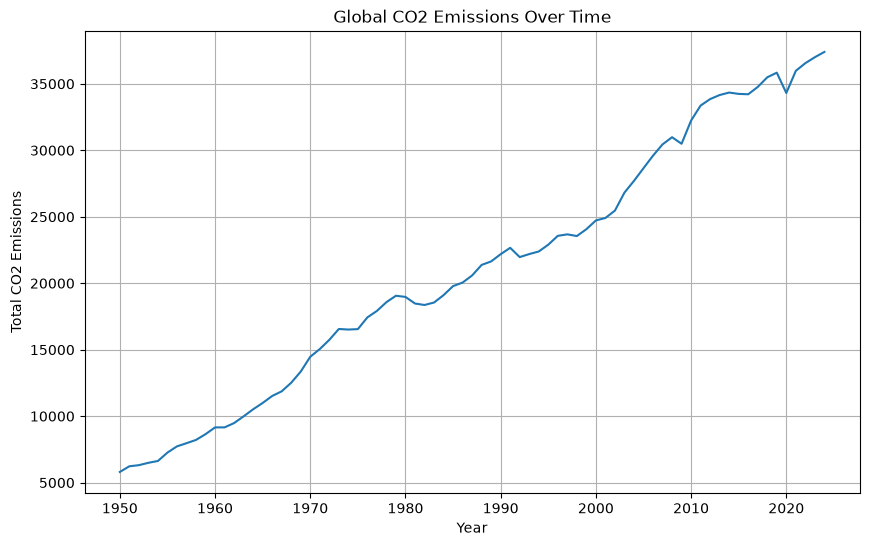

In [19]:
# create a line plot that shows the total co2 emissions over time. i want to show the global emissions.
df_global = df_cleaned.groupby('year')['co2'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(df_global['year'], df_global['co2'])
plt.title('Global CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions')
plt.grid(True)
plt.show()

Global CO₂ emissions show a strong long-term upward trend, rising substantially from 1950 to the most recent years. The main noticeable declines occur around the early 1980s and early 1990s, periods associated with economic slowdowns and reduced energy demand. A sharper decline occurs around 2009 following the global financial crisis, while the largest recent drop is around 2020, largely associated with COVID-19 restrictions that temporarily reduced transportation, industrial activity, and energy use. Emissions rebounded quickly afterward and reached new highs, showing that the overall long-term trend remains upward.

### 5.2. Top 10 Countries by Total CO₂ Emissions

/tmp/ipykernel_1639/1932435029.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


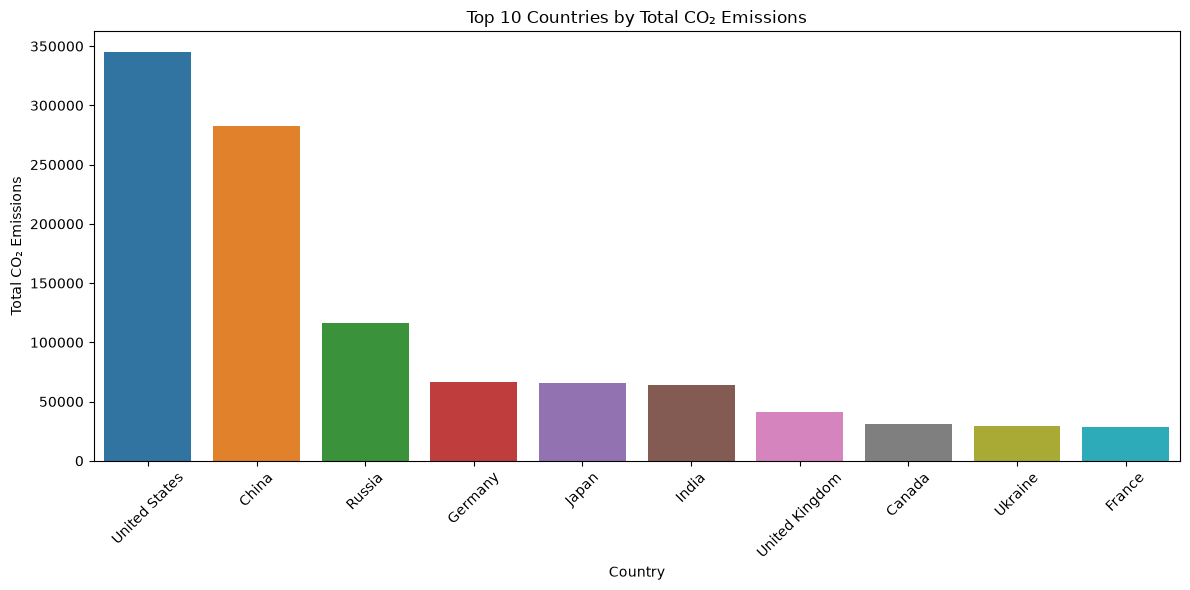

In [20]:
top_emitters = df_cleaned.groupby("country")["co2"].sum().nlargest(10)


# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))


plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.3. CO₂ Emissions Trends of Top 5 Emitting Countries

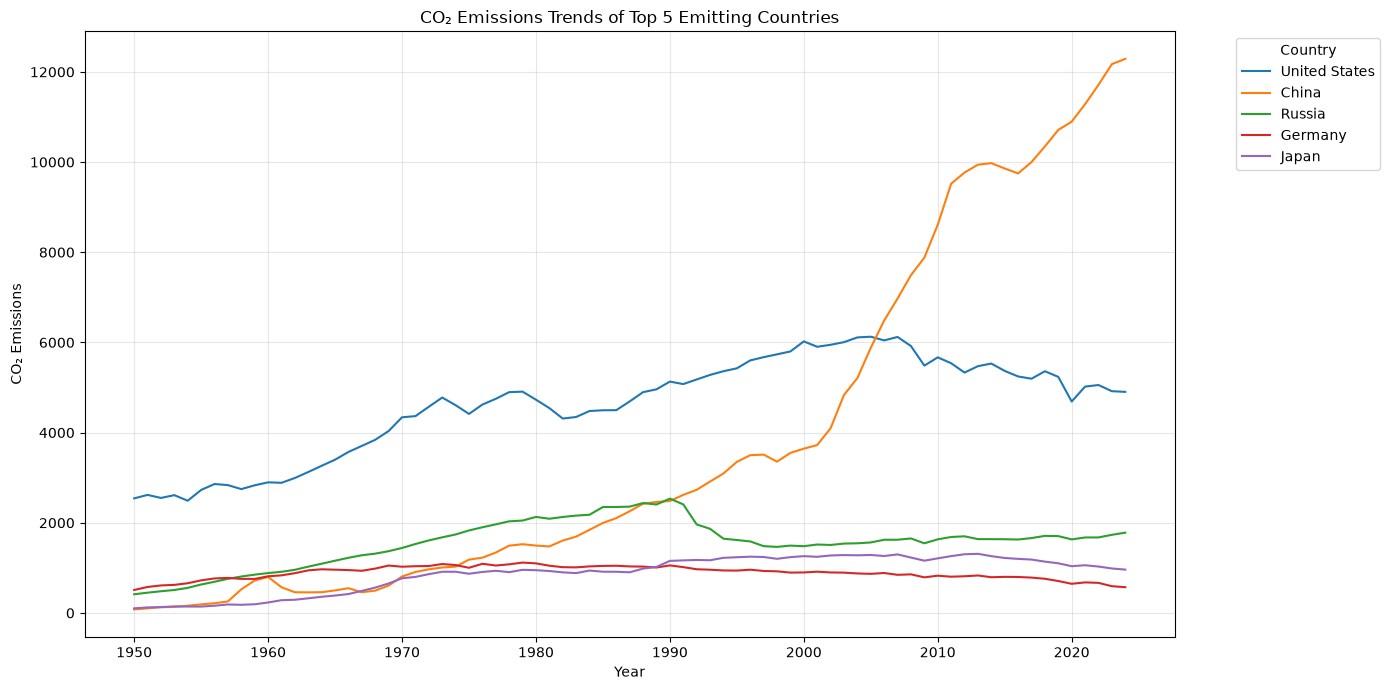

In [21]:
# Identify the top 5 countries by total CO₂ emissions
top_5_countries = top_emitters.head(5).index

top_countries_df = df_cleaned[
    df_cleaned["country"].isin(top_5_countries)
]

plt.figure(figsize=(14, 7))

# Plot each country separately
for country in top_5_countries:
    country_data = top_countries_df[
        top_countries_df["country"] == country
    ].sort_values("year")

    plt.plot(
        country_data["year"],
        country_data["co2"],
        label=country
    )

plt.title("CO₂ Emissions Trends of Top 5 Emitting Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### 5.4. Annual Percentage Change in CO₂ Emissions

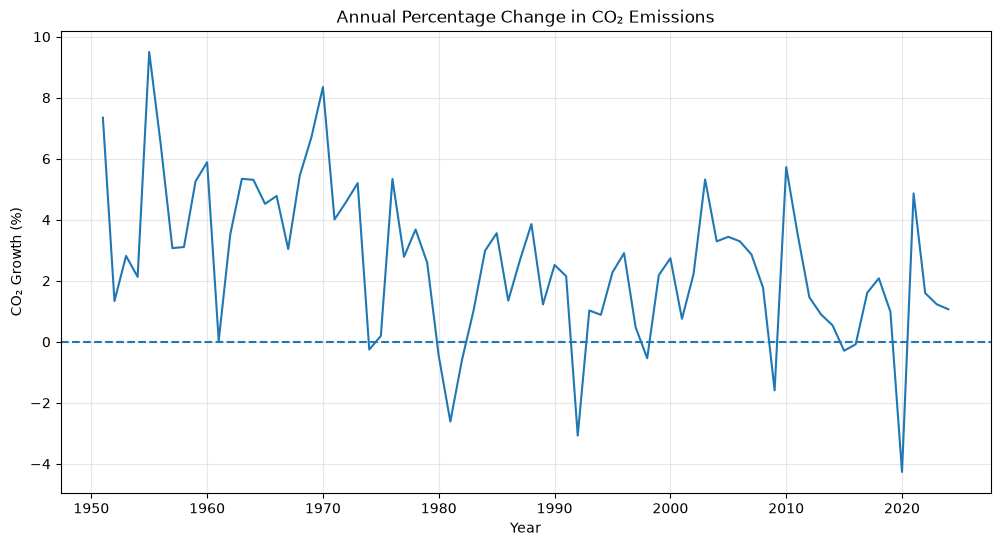

In [22]:
# Plot annual CO₂ growth rate
# calculate growth rate of co2 emissions over time for a time series analysis. The growth rate is calculated as the percentage change in co2 emissions from one year to the next.
df_global['co2_growth_rate'] = df_global['co2'].pct_change() * 100

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_global,
    x="year",
    y="co2_growth_rate"
)

plt.axhline(0, linestyle="--")

plt.title("Annual Percentage Change in CO₂ Emissions")
plt.xlabel("Year")
plt.ylabel("CO₂ Growth (%)")
plt.grid(True, alpha=0.3)

plt.show()

The explanations for the trends are explained in 5.1 above

## 6. Feature Engineering & Importance

## 7. Modeling